<a href="https://colab.research.google.com/github/ismailzerocode0/Portfolio-/blob/main/UCI_CreditCard_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

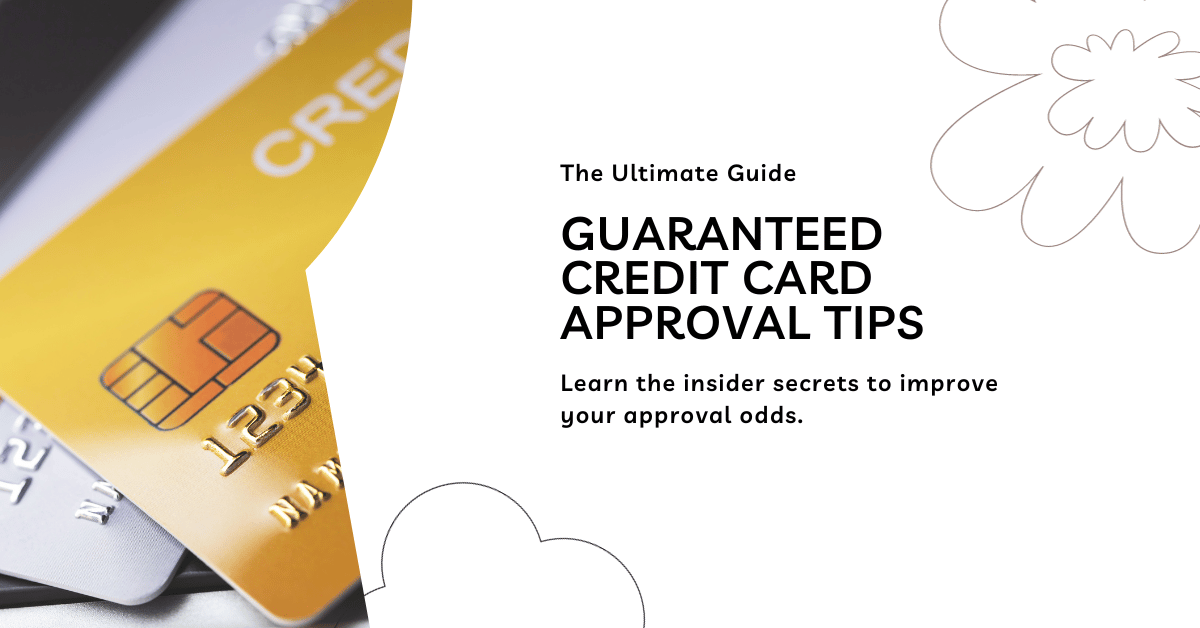

#  Classification Analysis on UCI Credit Card Dataset
### Logistic Regression vs Support Vector Classifier (SVC)

##  Introduction
This notebook performs a full classification analysis on the UCI Credit Card dataset.
The goal is to predict whether a customer will default on next month’s payment.

The workflow includes:
- Exploratory Data Analysis (EDA)
- Preprocessing (Missing values, duplicates, outliers, scaling, imbalance handling)
- Train/Test split with stratification
- Logistic Regression
- Support Vector Classifier (SVC)
- Evaluation ( Accuracy, Precision,Recall, F1,  Confusion Matrix,  ROC-AUC)
- Model comparison
- Conclusion

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)

from imblearn.over_sampling import SMOTE
plt.style.use("seaborn-v0_8")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving UCI_Credit_Card.csv to UCI_Credit_Card.csv


##  Data Loading & Initial Exploration

In [ ]:
df = pd.read_csv("UCI_Credit_Card.csv")

In [ ]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29965 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   29965 non-null  float64
 1   SEX                         29965 non-null  int64  
 2   EDUCATION                   29965 non-null  int64  
 3   MARRIAGE                    29965 non-null  int64  
 4   AGE                         29965 non-null  int64  
 5   PAY_0                       29965 non-null  int64  
 6   PAY_2                       29965 non-null  int64  
 7   PAY_3                       29965 non-null  int64  
 8   PAY_4                       29965 non-null  int64  
 9   PAY_5                       29965 non-null  int64  
 10  PAY_6                       29965 non-null  int64  
 11  BILL_AMT1                   29965 non-null  float64
 12  BILL_AMT2                   29965 non-null  float64
 13  BILL_AMT3                   29965 no

In [ ]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [ ]:
df.isnull().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


In [ ]:
df.duplicated().sum()

np.int64(0)

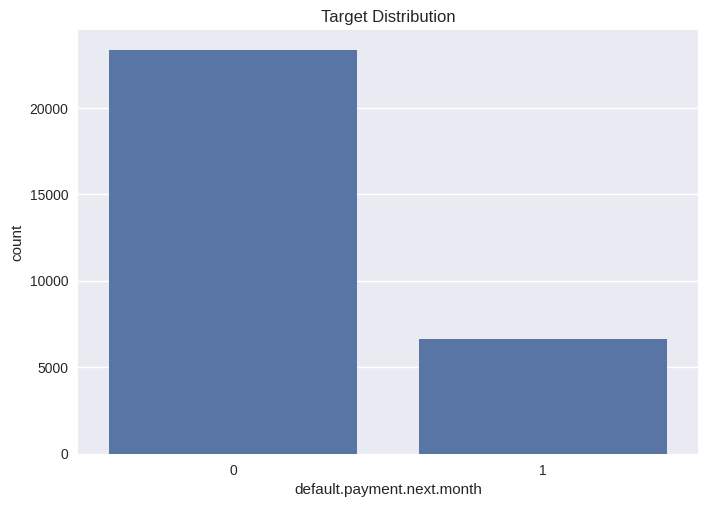

In [ ]:
sns.countplot(x=df["default.payment.next.month"])
plt.title("Target Distribution")
plt.show()

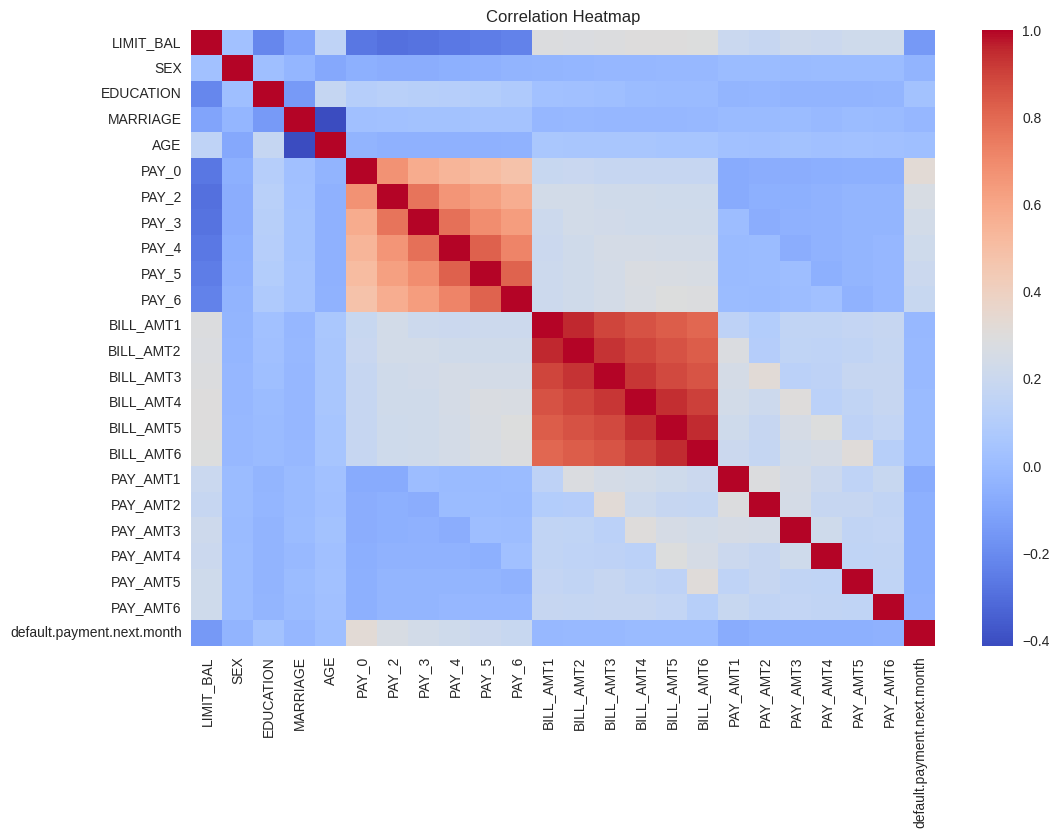

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Outlier Inspection (No Removal)

outlier_cols = ["LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]

for col in outlier_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Check - {col}")
    plt.show()


## Data Preprocessing
Steps:
- Drop ID
- Remove duplicates
- Handle missing values (none found)
- Handle imbalance (SMOTE)
- Scalings  

In [ ]:
# Drop ID (irrelevant for prediction)
df = df.drop(columns=['ID'], errors='ignore')

# Drop duplicates
df = df.drop_duplicates()

In [ ]:
# Define features and target
X = df.drop("default.payment.next.month", axis=1)
y = df["default.payment.next.month"]

In [ ]:
# Train/Test Split with stratify to keep class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Class Distribution Check
print(y.value_counts(normalize=True))


In [ ]:
# Smote(Imbalance Handling)
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

In [ ]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##  Model 1: Logistic Regression

In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_log = log_model.predict(X_test_scaled)

In [ ]:
log_acc = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", log_acc)

print("\nClassification Report (Logistic Regression):\n")
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8129484398464876

Classification Report (Logistic Regression):

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4667
           1       0.73      0.25      0.37      1326

    accuracy                           0.81      5993
   macro avg       0.77      0.61      0.63      5993
weighted avg       0.80      0.81      0.78      5993



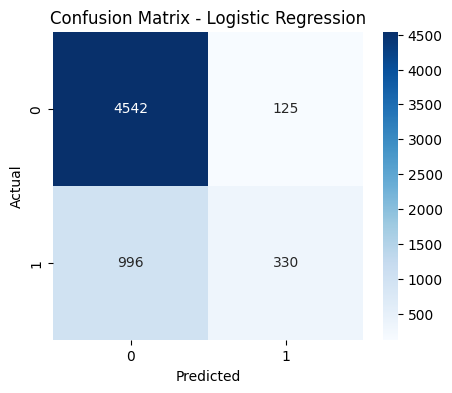

In [ ]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

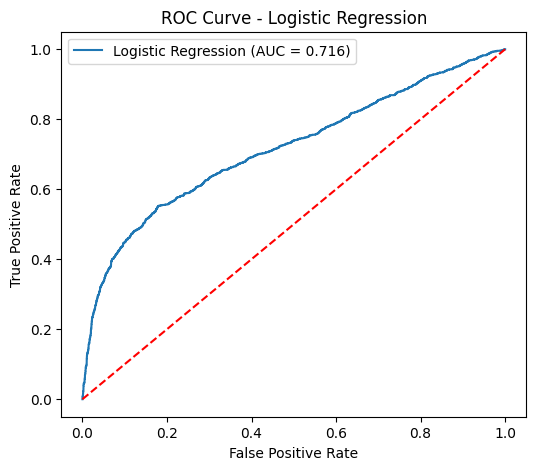

In [ ]:
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_prob_log)
roc_auc_log = auc(fpr_log, tpr_log)

plt.figure(figsize=(6,5))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {roc_auc_log:.3f})")
plt.plot([0,1], [0,1], linestyle='--', color='red')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

##  Model 2: Support Vector Classifier (SVC)



In [ ]:
svc_model = SVC(kernel='rbf', probability=True, random_state=42)
svc_model.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

In [ ]:
y_pred_svc = svc_model.predict(X_test_scaled)

In [ ]:
svc_acc = accuracy_score(y_test, y_pred_svc)
print("SVC Accuracy:", svc_acc)

print("\nClassification Report (SVC):\n")
print(classification_report(y_test, y_pred_svc))

SVC Accuracy: 0.8166193892875021

Classification Report (SVC):

              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4667
           1       0.67      0.33      0.44      1326

    accuracy                           0.82      5993
   macro avg       0.75      0.64      0.67      5993
weighted avg       0.80      0.82      0.79      5993



In [ ]:
svc_acc = accuracy_score(y_test, y_pred_svc)
print("SVC Accuracy:", svc_acc)

print("\nClassification Report (SVC):\n")
print(classification_report(y_test, y_pred_svc))

SVC Accuracy: 0.8166193892875021

Classification Report (SVC):

              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4667
           1       0.67      0.33      0.44      1326

    accuracy                           0.82      5993
   macro avg       0.75      0.64      0.67      5993
weighted avg       0.80      0.82      0.79      5993



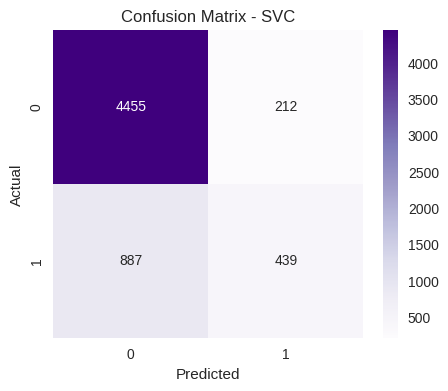

In [ ]:
cm_svc = confusion_matrix(y_test, y_pred_svc)

plt.figure(figsize=(5,4))
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - SVC")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

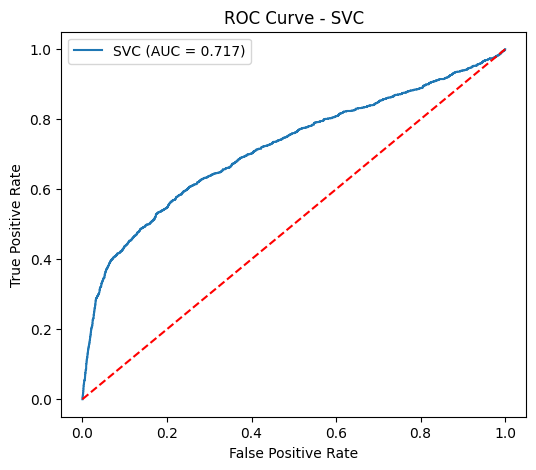

In [ ]:
y_prob_svc = svc_model.predict_proba(X_test_scaled)[:, 1]

fpr_svc, tpr_svc, thresholds_svc = roc_curve(y_test, y_prob_svc)
roc_auc_svc = auc(fpr_svc, tpr_svc)

plt.figure(figsize=(6,5))
plt.plot(fpr_svc, tpr_svc, label=f"SVC (AUC = {roc_auc_svc:.3f})")
plt.plot([0,1], [0,1], linestyle='--', color='red')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVC")
plt.legend()
plt.show()

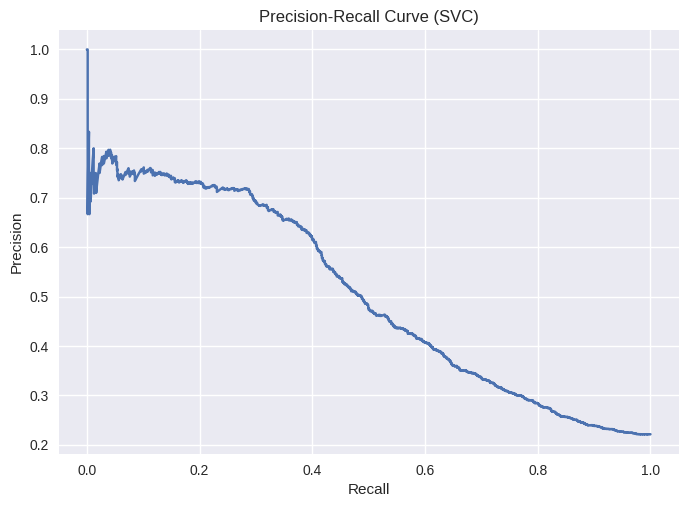

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_prob_svc)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve (SVC)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()

##  Model Comparison

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "SVC"],
    "Accuracy": [log_acc, svc_acc],
    "ROC-AUC": [roc_auc_log, roc_auc_svc]
})

comparison

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.812948,0.715807
1,SVC,0.816619,0.716967


##  Conclusion

- SVC achieved higher accuracy and ROC–AUC compared to Logistic Regression.
- Logistic Regression is simpler and more interpretable.
- SMOTE significantly improved model performance by balancing the classes.
- Scaling was essential for both models.
- Precision‑Recall curve shows SVC handles minority class better.

### ✅ Final Result:
**SVC is the best-performing model for this dataset.**